In [1]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle

from scipy import spatial

In [2]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if int(a) == 0 and b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if int(a) == 0 and b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

## Load MD data

In [3]:
def load_simulation(glob_pattern, top_path, subsampling=1, atom_selection='(element != H) and is_protein', Ca_only=True, center=True):

    md_files = sorted(glob(glob_pattern))
    print(f"found {len(md_files)} trajectory files...")
    
    md_sim = None

    for f in tqdm(md_files):
    
        t = md.load(f, top=top_path)[::subsampling]
    
        idx = t.top.select(atom_selection)
        t   = t.atom_slice(idx)

        if Ca_only:
            idx = t.top.select('name == CA')
            t   = t.atom_slice(idx)
    
        if md_sim == None:
            md_sim = t
        else:
            md_sim += t

    if center:
        md_sim = md_sim.center_coordinates()
    
    return md_sim

In [4]:
# DESRES
# sampling is 1 ns, so subsampled 1/1 is 1 ns

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
glob_pattern = prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'
top_path = prefix + '/system_nowat.pdb'

desres_sim = load_simulation(glob_pattern, top_path, subsampling=1)

  0%|          | 0/100 [00:00<?, ?it/s]

found 100 trajectory files...


100%|██████████| 100/100 [01:43<00:00,  1.04s/it]


In [5]:
# RIKEN
# sampling is 200 ps, so subsampled 1/5 is 1 ns

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/RIKEN_mpro_simulation'
glob_pattern = prefix + '/Traj?/protein_snap_every200ps_*.xtc'
top_path = prefix + '/Traj1/protein_conf.gro'

riken_sim = load_simulation(glob_pattern, top_path, subsampling=5)
riken_sim = riken_sim.superpose(riken_sim[0])

  0%|          | 0/6 [00:00<?, ?it/s]

found 6 trajectory files...


100%|██████████| 6/6 [00:49<00:00,  8.30s/it]


In [6]:
# GaMD
# 200 ps sampling

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/TRAJECTORIES_main_protease_6LU7_amarolab/6LU7_dimer_apo'

glob_pattern_combined = prefix + '/*/6LU7_dimer_apo.nc'
top_path_combined = prefix + '/6LU7_dimer_apo.prmtop'

amaro_sim = load_simulation(glob_pattern_combined, top_path_combined, subsampling=5, center=True)
amaro_sim = amaro_sim.superpose(amaro_sim[0])

  0%|          | 0/5 [00:00<?, ?it/s]

found 5 trajectory files...


100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


In [7]:
print(desres_sim.xyz.shape)
print(riken_sim.xyz.shape)
print(amaro_sim.xyz.shape)

(100000, 612, 3)
(20000, 612, 3)
(1000, 612, 3)


In [8]:
active_site_A_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 1
active_site_B_residues = active_site_A_residues + 306

residues = list(desres_sim.top.residues)
asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in active_site_B_residues ]

print(asr_names)

['HIS41', 'MET49', 'GLY143', 'SER144', 'CYS145', 'HIS163', 'HIS164', 'MET165', 'GLU166', 'LEU167', 'ASP187', 'ARG188', 'GLN189', 'THR190', 'ALA191', 'GLN192']


## Compute Ca covariance tensor

In [9]:
def isotropic_cov(xyz):
    
    # we want X.T * X summed over last dim
    # put it in B-factor units
    S = 8.0 * np.square(np.pi) * ( np.cov(xyz[:,:,0].T) + np.cov(xyz[:,:,1].T) + np.cov(xyz[:,:,2].T) )
    
    return S

In [10]:
S_desres = isotropic_cov(desres_sim.xyz)
S_riken  = isotropic_cov(riken_sim.xyz)
S_amaro = isotropic_cov(amaro_sim.xyz)

for S in [S_desres, S_riken, S_amaro]:
    print(S.shape)

(612, 612)
(612, 612)
(612, 612)


132.8709436211427


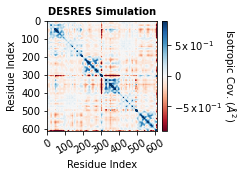

148.33207147749448


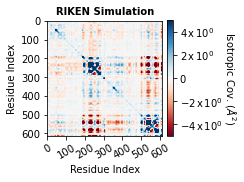

89.12272635958978


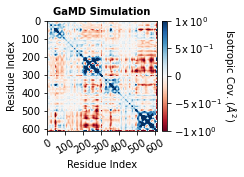

In [11]:
ticks = np.arange(0, desres_sim.xyz.shape[1], 100)
cmap = 'RdBu'

# title, matrix to plot, filename to save
datasets = [
    ('DESRES Simulation', S_desres[:,:], "desres_sim"),
    ('RIKEN Simulation', S_riken[:,:], "riken_sim"),
    ('GaMD Simulation', S_amaro[:,:], "amaro_sim"),
]


# how much to zoom colorbar
scales = [
    0.9,
    5.0,
    1,
]

for i_d, dataset in enumerate(datasets):

    figsize = (3.5,3.5)

    fig = plt.figure(figsize=figsize)
    ax1 = plt.subplot(111)

    ax1.set_title(dataset[0], 
                  fontweight='bold', fontsize=10)
    

    print(dataset[1].max())
    im = ax1.imshow(
        dataset[1],
        cmap=cmap, 
        vmin=-scales[i_d],
        vmax=scales[i_d],
        interpolation=None,
    )

    ax1.set_xticks(ticks)
    plt.xticks(rotation=30)
    ax1.set_xticklabels([str(int(t)) for t in ticks])
    ax1.set_yticks(ticks)
    ax1.set_yticklabels([str(int(t)) for t in ticks])
    ax1.set_xlabel('Residue Index')
    ax1.set_ylabel('Residue Index')
    
    # ax1.set_xticks([])
    # ax1.set_yticks([])

    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, format=FuncFormatter(sci_notation_no_sigfigs))
    
    cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.savefig(f'./figures/covariance_matrices/{dataset[2]}.pdf')
    plt.show()

    np.save(f"./covariance_matrices/{dataset[2]}.npy", dataset[1][:303,:303]) # make it the same shape as the expt ones

In [12]:
mu_desres_A = np.abs(S_desres[active_site_A_residues,:]).mean(0)
mu_desres_B = np.abs(S_desres[:,active_site_B_residues]).mean(1)

mu_riken_A = np.abs(S_riken[active_site_A_residues,:]).mean(0)
mu_riken_B = np.abs(S_riken[:,active_site_B_residues]).mean(1)

mu_amaro_A = np.abs(S_amaro[active_site_A_residues,:]).mean(0)
mu_amaro_B = np.abs(S_amaro[:,active_site_B_residues]).mean(1)

print(S_desres.shape)

(612, 612)


## View correlation projected on active site

In [13]:
res_idx = np.arange(S_desres.shape[0]) + 1

In [17]:
hotspot_residues = np.array([214, 256, 284, 214+306, 256+306, 284+306]) - 1

for sim in [desres_sim, riken_sim, amaro_sim]:
    residues = list(sim.top.residues)
    asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in hotspot_residues ] 
    print(asr_names)

['ASN214', 'GLN256', 'SER284', 'ASN214', 'GLN256', 'SER284']
['ASN214', 'GLN256', 'SER284', 'ASN214', 'GLN256', 'SER284']
['ASN213', 'GLN255', 'SER283', 'ASN519', 'GLN561', 'SER589']


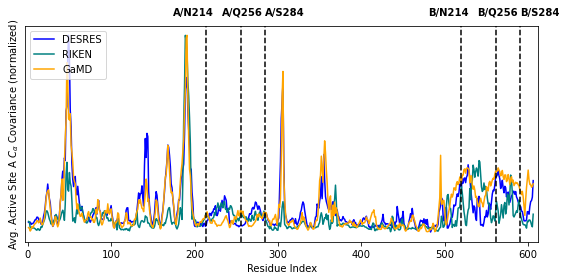

In [39]:
SEQUENCE_CUTOFF = 606
RESIDUES_OF_INTEREST = [214, 256, 284, 214+306, 256+306, 284+306]

plt.figure(figsize=(8,4))

ax1 = plt.subplot(111)

p1 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_desres_A[:SEQUENCE_CUTOFF] / mu_desres_A[:SEQUENCE_CUTOFF].max(), color='b')
p2 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_riken_A[:SEQUENCE_CUTOFF] / mu_riken_A[:SEQUENCE_CUTOFF].max(), color='teal')
p3 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_amaro_A[:SEQUENCE_CUTOFF] / mu_amaro_A[:SEQUENCE_CUTOFF].max(), color='orange')

ax1.set_xlabel('Residue Index')
ax1.set_ylabel(r'Avg. Active Site A $C_\alpha$ Covariance (normalized)')
ax1.set_yticks([])

x_shift = 15
ax1.text(214-x_shift - 25, 1.1,  'A/N214', weight='bold')
ax1.text(256-x_shift - 8, 1.105,  'A/Q256', weight='bold')
ax1.text(284-x_shift + 15, 1.1,  'A/S284', weight='bold')

ax1.text(214-x_shift + 306 - 25, 1.1,  'B/N214', weight='bold')
ax1.text(256-x_shift + 306 - 8, 1.105,  'B/Q256', weight='bold')
ax1.text(284-x_shift + 306 + 15, 1.1,  'B/S284', weight='bold')

for residue in RESIDUES_OF_INTEREST:
    ax1.axvline(x=residue, color="k", linestyle="--")

plt.legend(['DESRES', 'RIKEN', 'GaMD'], loc=2)

plt.xlim([-3, 612])

plt.tight_layout()
plt.savefig('figures/md_simulation_comparison_correlation_to_active_A.pdf')
plt.show()

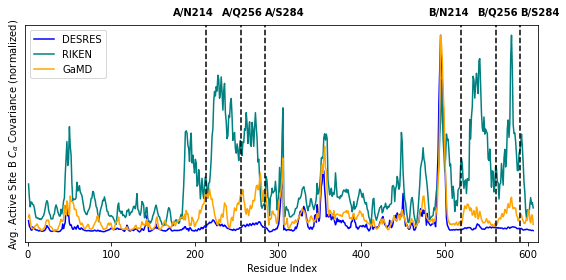

In [40]:
SEQUENCE_CUTOFF = 606
RESIDUES_OF_INTEREST = [214, 256, 284, 214+306, 256+306, 284+306]

plt.figure(figsize=(8,4))

ax1 = plt.subplot(111)

p1 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_desres_B[:SEQUENCE_CUTOFF] / mu_desres_B[:SEQUENCE_CUTOFF].max(), color='b')
p2 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_riken_B[:SEQUENCE_CUTOFF] / mu_riken_B[:SEQUENCE_CUTOFF].max(), color='teal')
p3 = ax1.plot(res_idx[:SEQUENCE_CUTOFF], mu_amaro_B[:SEQUENCE_CUTOFF] / mu_amaro_B[:SEQUENCE_CUTOFF].max(), color='orange')

ax1.set_xlabel('Residue Index')
ax1.set_ylabel(r'Avg. Active Site B $C_\alpha$ Covariance (normalized)')
ax1.set_yticks([])

x_shift = 15
ax1.text(214-x_shift - 25, 1.1,  'A/N214', weight='bold')
ax1.text(256-x_shift - 8, 1.105,  'A/Q256', weight='bold')
ax1.text(284-x_shift + 15, 1.1,  'A/S284', weight='bold')

ax1.text(214-x_shift + 306 - 25, 1.1,  'B/N214', weight='bold')
ax1.text(256-x_shift + 306 - 8, 1.105,  'B/Q256', weight='bold')
ax1.text(284-x_shift + 306 + 15, 1.1,  'B/S284', weight='bold')

for residue in RESIDUES_OF_INTEREST:
    ax1.axvline(x=residue, color="k", linestyle="--")

plt.legend(['DESRES', 'RIKEN', 'GaMD'], loc=2)

plt.xlim([-3, 612])

plt.tight_layout()
plt.savefig('figures/md_simulation_comparison_correlation_to_active_B.pdf')
plt.show()